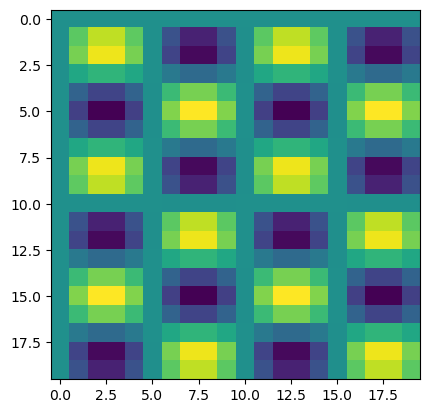

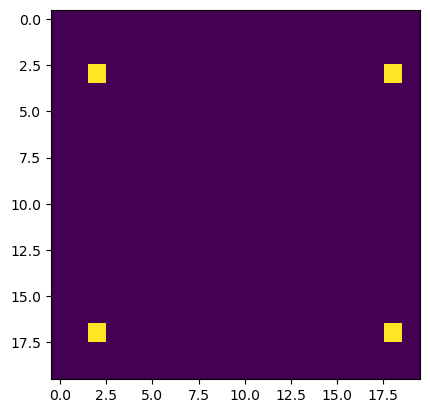

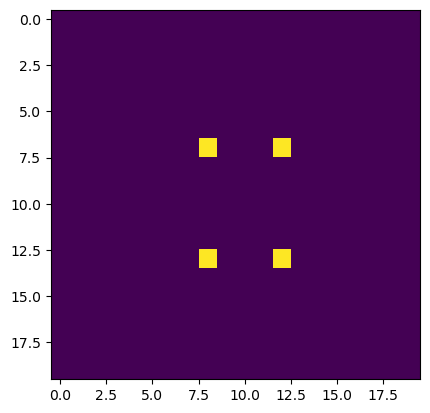

In [5]:
""" 
Premiers exemples d'utilisation de la FFT en dimension 2
"""

import numpy as np           
from PIL import Image 
import matplotlib.pyplot as plt 

from math import pi
N=20
x=np.arange(0,N)*2*pi/N
y=np.arange(0,N)*2*pi/N
X,Y=np.meshgrid(x,y)
F=np.sin(2*X)*np.sin(3*Y)
plt.imshow(F);plt.show()
CoefF = np.fft.fft2(F)
m,n=F.shape
CoefF/=(m*n)
plt.imshow(np.abs(CoefF));plt.show()

CoefFShift = np.fft.fftshift(CoefF)

plt.imshow(np.abs(CoefFShift));  # pour faire un zoom utiliser extent
plt.show() 


Hauteur = 1892
Largeur = 2602


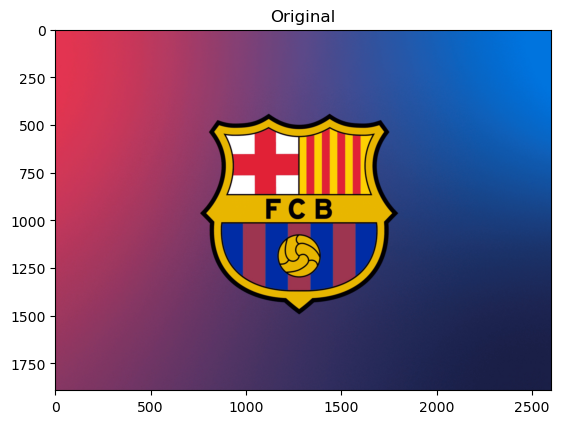

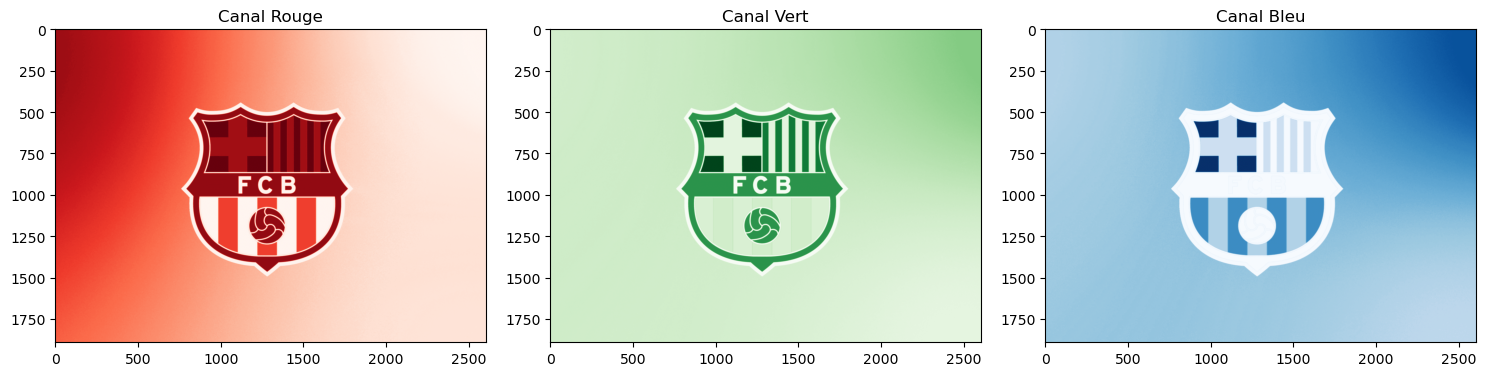

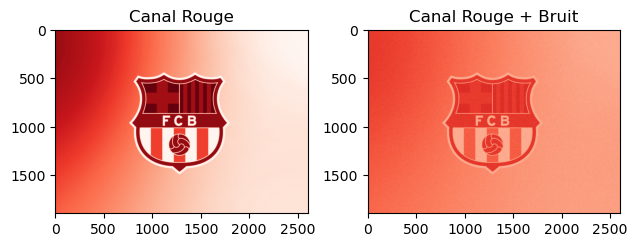

In [41]:
image="C:\\Users\\polti\\OneDrive\\Documents\\Sorbonne\\Fourier Discrète\\Test.jpg"
img = Image.open(image).convert("RGB")  
u = np.array(img)                           

#image originale
plt.figure()
plt.imshow(img) 
plt.title("Original") 

# Dimensions de l'image
m, n = u.shape[:2]  # hauteur et largeur
print("Hauteur =", m)
print("Largeur =", n)

#extraction d'un canal couleur d'un tableau NumPy u Ã  3 canaux
R = u[:, :, 0]     #canal rouge
G = u[:, :, 1]     #canal vert
B = u[:, :, 2]     #canal bleu

#affichage des trois canaux
plt.figure(figsize=(15,5))
plt.subplot(131);plt.imshow(R, cmap='Reds'); plt.title("Canal Rouge") 
plt.subplot(132);plt.imshow(G, cmap='Greens'); plt.title("Canal Vert") 
plt.subplot(133);plt.imshow(B, cmap='Blues'); plt.title("Canal Bleu")
plt.tight_layout()
plt.show()

# ajout de bruit blanc gaussien 
bruit = np.random.normal(0,45,(m,n))  
Rb=R+ + bruit
plt.subplot(121);plt.imshow(R, cmap='Reds'); plt.title("Canal Rouge")
plt.subplot(122);plt.imshow(Rb, cmap='Reds'); plt.title("Canal Rouge + Bruit")
plt.tight_layout()
plt.show()
#

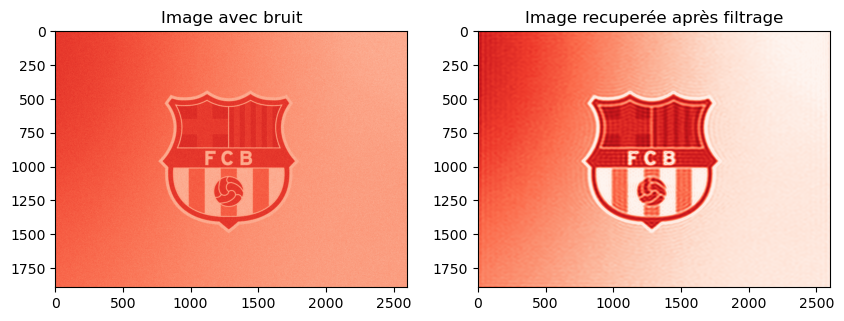

In [47]:
#On essaye de récupérer l'image originale à partir de sa FFT
#On applique donc le filtre passe bas en tronquant les coefficients de la FFT

Rb = np.array(Rb)
m, n = Rb.shape
CoefImage = np.fft.fft2(Rb)
#On applique le filtre pass-bas pour éliminer les hautes fréquences et récupérer une image plus lisse
CoefImageShift = np.fft.fftshift(CoefImage)
espectre_visible = np.log(1 + np.abs(CoefImageShift))

#On definit le parametre de tronquage et on trouve le centre de l'image
N = 70
c_row, c_col = m//2, n//2
#On tronque les coefficients de la FFT en gardant seulement les N*N coefficients les plus proches du centre
CoefImageShift_tronque = np.zeros_like(CoefImageShift)
CoefImageShift_tronque[c_row-N:c_row+N, c_col-N:c_col+N] = CoefImageShift[c_row-N:c_row+N, c_col-N:c_col+N]

#on recupere l'image tronquee en appliquant la FFT inverse
CoefImage_tronque = np.fft.ifftshift(CoefImageShift_tronque)
Image_tronquee = np.fft.ifft2(CoefImage_tronque)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(Rb, cmap='Reds')
ax[0].set_title("Image avec bruit")
ax[1].imshow(np.abs(Image_tronquee), cmap='Reds')
ax[1].set_title("Image recuperée après filtrage")
plt.show()

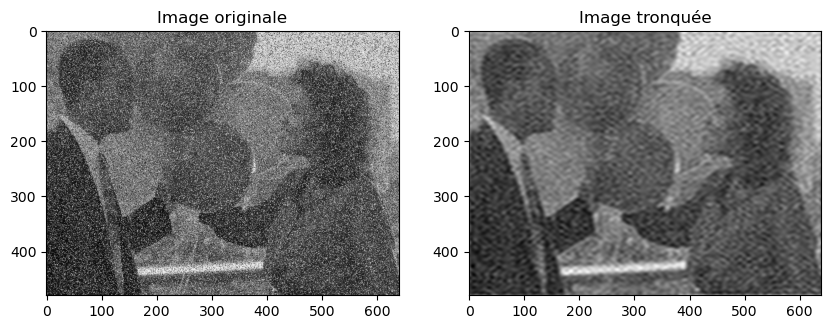

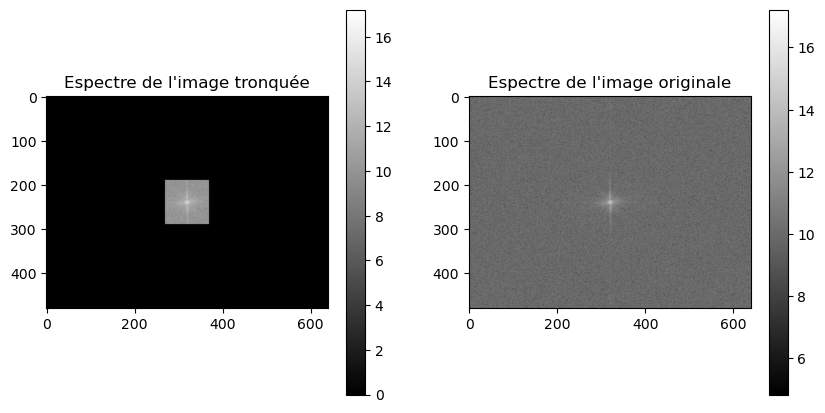

In [40]:
image="C:\\Users\\polti\\OneDrive\\Documents\\Sorbonne\\Fourier Discrète\\Test2.jpg"
img = Image.open(image).convert("L") 
u = np.array(img)
m, n = u.shape
CoefImage = np.fft.fft2(u)
#On applique le filtre pass-bas pour éliminer les hautes fréquences et récupérer une image plus lisse
CoefImageShift = np.fft.fftshift(CoefImage)
espectre_visible = np.log(1 + np.abs(CoefImageShift))

#On definit le parametre de tronquage et on trouve le centre de l'image
N = 50
c_row, c_col = m//2, n//2
#On tronque les coefficients de la FFT en gardant seulement les N*N coefficients les plus proches du centre
CoefImageShift_tronque = np.zeros_like(CoefImageShift)
CoefImageShift_tronque[c_row-N:c_row+N, c_col-N:c_col+N] = CoefImageShift[c_row-N:c_row+N, c_col-N:c_col+N]

#on recupere l'image tronquee en appliquant la FFT inverse
CoefImage_tronque = np.fft.ifftshift(CoefImageShift_tronque)
Image_tronquee = np.fft.ifft2(CoefImage_tronque)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(u, cmap='gray')
ax[0].set_title("Image originale")
ax[1].imshow(np.abs(Image_tronquee), cmap='gray')
ax[1].set_title("Image tronquée")
plt.show()

#Regardons l'espectre de la FFT de l'image tronquée
CoefImage_tronque_shift = np.fft.fftshift(CoefImage_tronque)
espectre_tronque_visible = np.log(1 + np.abs(CoefImage_tronque_shift))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(espectre_tronque_visible, cmap='gray')
ax[0].set_title("Image tronquée")
ax[1].imshow(espectre_visible, cmap='gray')
ax[1].set_title("Image originale")
ax[0].set_title("Espectre de l'image tronquée")
ax[1].set_title("Espectre de l'image originale")
ax[1].set_colorbar = plt.colorbar(ax[1].imshow(espectre_visible, cmap='gray'), ax=ax[1])
ax[0].set_colorbar = plt.colorbar(ax[0].imshow(espectre_tronque_visible, cmap='gray'), ax=ax[0])
plt.show()


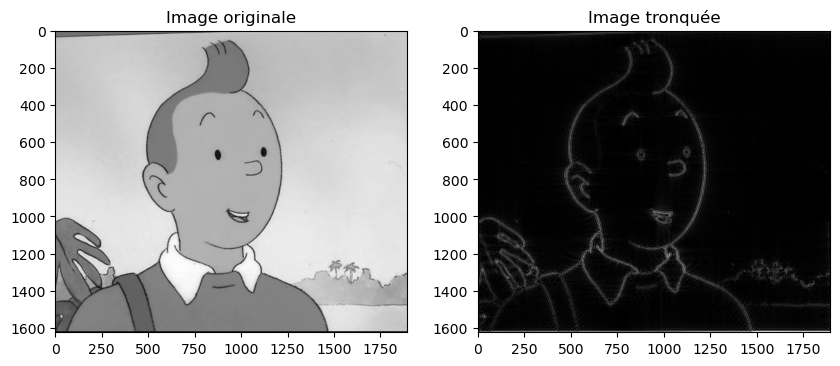

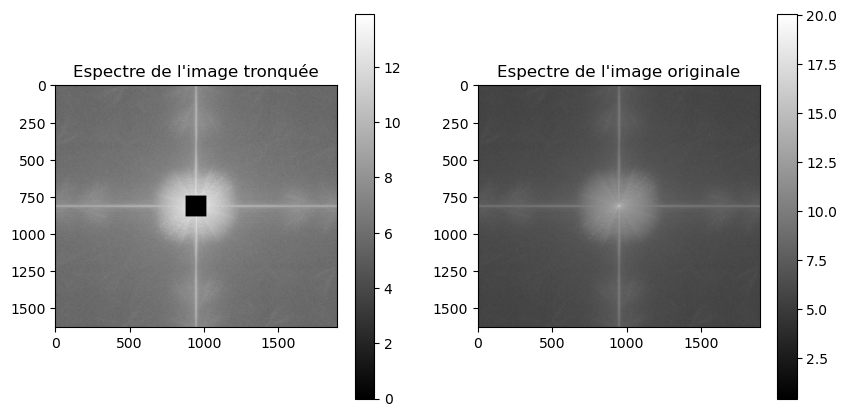

In [33]:
image="C:\\Users\\polti\\OneDrive\\Documents\\Sorbonne\\Fourier Discrète\\Test3.jpg"
img = Image.open(image).convert("L") 
u = np.array(img)
m, n = u.shape
CoefImage = np.fft.fft2(u)
#On applique le filtre pass-bas pour éliminer les hautes fréquences et récupérer une image plus lisse
CoefImageShift = np.fft.fftshift(CoefImage)
espectre_visible = np.log(1 + np.abs(CoefImageShift))

#On definit le parametre de tronquage et on trouve le centre de l'image
N = 70
c_row, c_col = m//2, n//2
#On tronque les coefficients de la FFT en gardant seulement les N*N coefficients les plus proches du centre
CoefImageShift_tronque = CoefImageShift.copy()
CoefImageShift_tronque[c_row-N:c_row+N, c_col-N:c_col+N] = 0

#on recupere l'image tronquee en appliquant la FFT inverse
CoefImage_tronque = np.fft.ifftshift(CoefImageShift_tronque)
Image_tronquee = np.fft.ifft2(CoefImage_tronque)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(u, cmap='gray')
ax[0].set_title("Image originale")
ax[1].imshow(np.abs(Image_tronquee), cmap='gray')
ax[1].set_title("Image tronquée")
plt.show()

#Regardons l'espectre de la FFT de l'image tronquée
CoefImage_tronque_shift = np.fft.fftshift(CoefImage_tronque)
espectre_tronque_visible = np.log(1 + np.abs(CoefImage_tronque_shift))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(espectre_tronque_visible, cmap='gray')
ax[0].set_title("Image tronquée")
ax[1].imshow(espectre_visible, cmap='gray')
ax[1].set_title("Image originale")
ax[0].set_title("Espectre de l'image tronquée")
ax[1].set_title("Espectre de l'image originale")
ax[1].set_colorbar = plt.colorbar(ax[1].imshow(espectre_visible, cmap='gray'), ax=ax[1])
ax[0].set_colorbar = plt.colorbar(ax[0].imshow(espectre_tronque_visible, cmap='gray'), ax=ax[0])
plt.show()
